In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load dataset

Dataset IEEE-CIS Fraud Detection terdiri dari dua tabel terpisah: `train_transaction.csv` (berisi data transaksi utama seperti nominal, produk, dan kartu pembayaran) dan `train_identity.csv` (berisi data tambahan seperti jenis device dan jaringan, hanya tersedia untuk sebagian transaksi). Kedua tabel digabungkan menggunakan kolom kunci `TransactionID` dengan metode `left join`, sehingga seluruh baris pada tabel transaksi tetap dipertahankan meskipun data identity-nya tidak tersedia.

Fitur tabel transaction

- TransactionID: ID unik transaksi, untuk join antar tabel
- isFraud: label target (1 = fraud, 0 = tidak fraud)
- TransactionDT: waktu transaksi, relatif dalam detik (bukan tanggal asli)
- TransactionAmt: nominal transaksi (USD)
- ProductCD: kode jenis produk/transaksi (W, C, R, H, S)
- card1–card6: info kartu pembayaran (jenis, bank penerbit, kategori)
- addr1, addr2: kode alamat/region pembeli (dianonimkan)
- dist1, dist2: jarak (misalnya alamat penagihan vs pengiriman)
- P_emaildomain, R_emaildomain: domain email pembeli dan penerima
- C1–C14: fitur hitungan (jumlah alamat/kartu terkait entitas)
- D1–D15: fitur selisih waktu antar event
- M1–M9: fitur pencocokan (True/False, misalnya nama vs alamat)
- V1–V339: fitur rekayasa Vesta (ranking, counting, relasi entitas)

Fitur tabel identity

- DeviceType: kategori device (desktop/mobile)
- DeviceInfo: detail device (merek, model, browser, OS)
- id_01–id_11: fitur numerik jaringan/perilaku (fingerprint device)
- id_12–id_38: fitur kategorikal (versi browser, OS, sinyal perilaku)

In [3]:
data_tx = pd.read_csv("train_transaction.csv")
data_id = pd.read_csv("train_identity.csv")

# gabung dua tabel berdasarkan TransactionID
data = data_tx.merge(data_id, on="TransactionID", how="left")
print(data.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...                id_31  id_32  \
0    NaN  150.0    discover  142.0  ...                  NaN    NaN   
1  404.0  150.0  mastercard  102.0  ...                  NaN    NaN   
2  490.0  150.0        visa  166.0  ...                  NaN    NaN   
3  567.0  150.0  mastercard  117.0  ...                  NaN    NaN   
4  514.0  150.0  mastercard  102.0  ...  samsung browser 6.2   32.0   

       id_33           id_34  id_35 id_36 id_37  id_38  DeviceType  \
0        NaN             NaN    NaN   Na

# Eksplorasi Struktur Data

Tahap ini bertujuan untuk memahami dimensi dataset (jumlah baris dan kolom) serta tipe data dari setiap kolom. Informasi ini penting sebagai dasar untuk menentukan strategi preprocessing yang akan digunakan pada tahap berikutnya.

In [4]:
print(data.shape)
print(data.info())

(590540, 434)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB
None


# Missing value

Dataset ini memiliki banyak nilai kosong (missing value), terutama pada kolom-kolom hasil rekayasa fitur (`V`, `C`, `D`) dan kolom identity, karena tidak semua transaksi memiliki data identity yang lengkap. Tahap ini mengidentifikasi kolom mana saja yang memiliki proporsi missing value tertinggi sebagai dasar pengambilan keputusan pada tahap pembersihan data selanjutnya.

In [5]:
print(data.isnull().sum().sort_values(ascending=False).head(20))

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_03    524216
id_04    524216
D6       517353
id_33    517251
id_10    515614
dtype: int64


## Membuang Kolom dengan Missing Value Ekstrem

Kolom dengan proporsi missing value di atas 90% dianggap tidak lagi memberikan informasi yang cukup untuk dipelajari model, sehingga kolom-kolom tersebut dibuang dari dataset. Ambang batas 90% dipilih sebagai titik tengah yang umum digunakan agar tidak membuang terlalu banyak informasi (jika ambang terlalu rendah) maupun mempertahankan kolom yang hampir seluruhnya kosong (jika ambang terlalu tinggi).

In [6]:
# drop kolom yang missing-nya di atas 90%
missing_pct = data.isnull().sum() / len(data)
kolom_dibuang = missing_pct[missing_pct > 0.9].index.tolist()
data = data.drop(columns=kolom_dibuang)
print("Kolom dibuang:", kolom_dibuang)

# sisa missing value diisi, bukan didrop
data.isnull().sum()

Kolom dibuang: ['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']


TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 422, dtype: int64

## Isi missing value

In [7]:
kolom_kategorikal = data.select_dtypes(include="object").columns.tolist()
kolom_numerik = [c for c in data.columns if c not in kolom_kategorikal + ["TransactionID", "isFraud"]]

for c in kolom_numerik:
    data[c] = data[c].fillna(-999)
for c in kolom_kategorikal:
    data[c] = data[c].fillna("missing")

print(data.isnull().sum().sum())

0


# Tipe transaksi

Kolom `ProductCD` merepresentasikan kategori/jenis produk pada setiap transaksi. Distribusi kategori ini divisualisasikan menggunakan pie chart untuk melihat proporsi masing-masing jenis produk dalam dataset.

In [8]:
print(data["ProductCD"].value_counts())

import plotly.express as px
tipe = data["ProductCD"].value_counts()
figure = px.pie(values=tipe.values, names=tipe.index, hole=0.5,
                 title="Distribusi ProductCD")
figure.show()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


# Analisis Fraud Rate Berdasarkan Kategori

DeviceType
mobile     0.101662
desktop    0.065215
missing    0.021017
Name: isFraud, dtype: float64


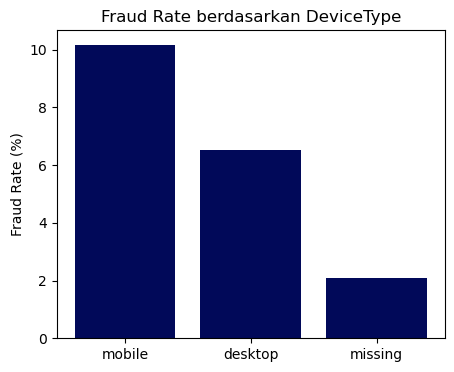

In [9]:
data["DeviceType"] = data["DeviceType"].fillna("unknown")

rate_device = data.groupby("DeviceType")["isFraud"].mean().sort_values(ascending=False)
print(rate_device)

plt.figure(figsize=(5,4))
plt.bar(rate_device.index, rate_device.values * 100, color="#010959")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate berdasarkan DeviceType")
plt.show()

ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64


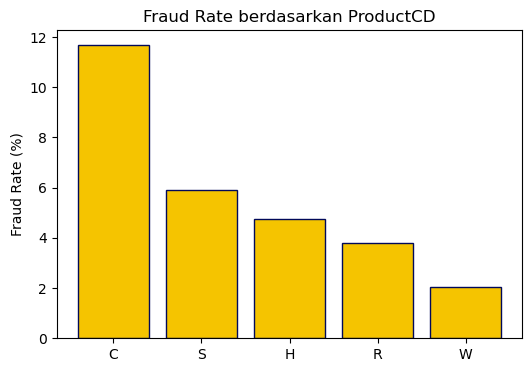

In [10]:
rate_product = data.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False)
print(rate_product)

plt.figure(figsize=(6,4))
plt.bar(rate_product.index, rate_product.values * 100, color="#F5C400", edgecolor="#010959")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate berdasarkan ProductCD")
plt.show()

##  Encoding Fitur Kategorikal

Algoritma machine learning hanya dapat memproses data numerik, sehingga seluruh kolom kategorikal (seperti `ProductCD`, `card4`, `card6`, `DeviceType`, dsb.) diubah menjadi bentuk numerik menggunakan `LabelEncoder`. Kolom `isFraud_label` juga dibuat sebagai representasi teks dari target (`Fraud` / `No Fraud`) untuk mempermudah interpretasi pada tahap visualisasi selanjutnya.

In [11]:
from sklearn.preprocessing import LabelEncoder

for c in kolom_kategorikal:
    le = LabelEncoder()
    data[c] = le.fit_transform(data[c])

data["isFraud_label"] = data["isFraud"].map({0: "No Fraud", 1: "Fraud"})
print(data.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt  ProductCD  card1  \
0        2987000        0          86400            68.5          4  13926   
1        2987001        0          86401            29.0          4   2755   
2        2987002        0          86469            59.0          4   4663   
3        2987003        0          86499            50.0          4  18132   
4        2987004        0          86506            50.0          1   4497   

   card2  card3  card4  card5  ...  id_32  id_33  id_34  id_35  id_36  id_37  \
0 -999.0  150.0      1  142.0  ... -999.0    260      4      2      2      2   
1  404.0  150.0      2  102.0  ... -999.0    260      4      2      2      2   
2  490.0  150.0      4  166.0  ... -999.0    260      4      2      2      2   
3  567.0  150.0      2  117.0  ... -999.0    260      4      2      2      2   
4  514.0  150.0      2  102.0  ...   32.0    164      3      1      0      1   

   id_38  DeviceType  DeviceInfo  isFraud_label  


C:\Users\USER\AppData\Local\Temp\ipykernel_13236\2036761619.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



## Analisis Korelasi

Tahap ini menghitung korelasi setiap fitur numerik terhadap variabel target `isFraud` untuk mengidentifikasi fitur-fitur yang memiliki hubungan paling kuat dengan terjadinya fraud. Hasil korelasi divisualisasikan dalam bentuk heatmap agar pola hubungan antar fitur lebih mudah diinterpretasikan secara visual.

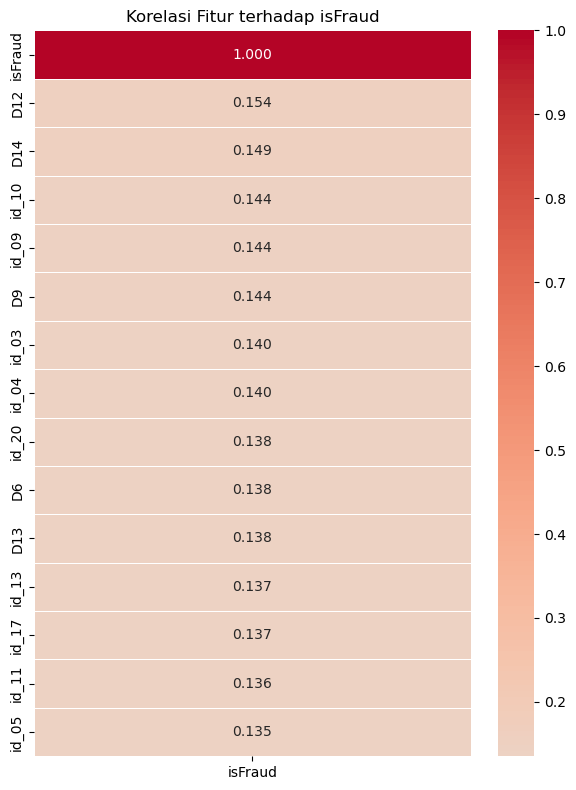

In [12]:
correlation = data.corr(numeric_only=True)
plt.figure(figsize=(6, 8))
top_corr_series = correlation["isFraud"].sort_values(ascending=False).head(15)

sns.heatmap(
    top_corr_series.to_frame(),
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Korelasi Fitur terhadap isFraud")
plt.tight_layout()
plt.show()

# Train Model

Pada tahap ini, dataset dibagi menjadi data latih (train) dan data uji (test) dengan proporsi 80:20 menggunakan stratifikasi berdasarkan target `isFraud`, untuk memastikan proporsi kelas fraud dan non-fraud tetap seimbang pada kedua subset data. Beberapa model klasifikasi kemudian dilatih dan dibandingkan performanya dalam mendeteksi transaksi fraud.

In [13]:
# ambil semua kolom KECUALI target dan ID (bukan fitur prediksi)
fitur = [c for c in data.columns if c not in ["TransactionID", "isFraud", "isFraud_label"]]
print("Jumlah fitur:", len(fitur))

x = np.array(data[fitur])
y = np.array(data["isFraud"])

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Jumlah fitur: 420


## 1. Decision tree

Decision Tree dipilih sebagai model baseline karena struktur pengambilan keputusannya yang transparan dan mudah diinterpretasikan (berupa serangkaian aturan if-else). Parameter `class_weight="balanced"` digunakan untuk mengatasi ketidakseimbangan kelas (hanya sekitar 3.5% transaksi yang bersifat fraud), sehingga model tidak bias terhadap kelas mayoritas (non-fraud).

In [14]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(class_weight="balanced", max_depth=10, random_state=42)
model_dt.fit(xtrain, ytrain)
print(model_dt.score(xtest, ytest))

0.8520760659735158


In [15]:
from sklearn.metrics import classification_report, roc_auc_score

ypred = model_dt.predict(xtest)
yproba = model_dt.predict_proba(xtest)[:, 1]

print(classification_report(ytest, ypred))
print("AUC-ROC:", roc_auc_score(ytest, yproba))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92    113975
           1       0.16      0.75      0.26      4133

    accuracy                           0.85    118108
   macro avg       0.57      0.80      0.59    118108
weighted avg       0.96      0.85      0.89    118108

AUC-ROC: 0.8643579836418469


In [16]:
idx_contoh = 0
transaksi_baru = xtest[idx_contoh].reshape(1, -1)

print("Label asli transaksi ini:", ytest[idx_contoh])
print("Prediksi model:", model_dt.predict(transaksi_baru))
print("Probabilitas:", model_dt.predict_proba(transaksi_baru))

Label asli transaksi ini: 0
Prediksi model: [0]
Probabilitas: [[0.88867645 0.11132355]]


## 2. Random Forest

Random Forest merupakan model ensemble yang membangun banyak Decision Tree secara acak dan menggabungkan hasil prediksinya melalui voting mayoritas. Pendekatan ini umumnya menghasilkan performa yang lebih baik dan lebih stabil dibandingkan satu Decision Tree tunggal, karena mampu mengurangi risiko overfitting.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=150, max_depth=16, min_samples_leaf=5,
    class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
model_rf.fit(xtrain, ytrain)
print("Random Forest score:", model_rf.score(xtest, ytest))

Random Forest score: 0.941291021776679


In [18]:
from sklearn.metrics import classification_report, roc_auc_score

ypred = model_rf.predict(xtest)
yproba = model_rf.predict_proba(xtest)[:, 1]

print(classification_report(ytest, ypred))
print("AUC-ROC:", roc_auc_score(ytest, yproba))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97    113975
           1       0.34      0.70      0.45      4133

    accuracy                           0.94    118108
   macro avg       0.66      0.82      0.71    118108
weighted avg       0.97      0.94      0.95    118108

AUC-ROC: 0.917386231131398


In [19]:
idx_contoh = 0
transaksi_baru = xtest[idx_contoh].reshape(1, -1)

print("Label asli transaksi ini:", ytest[idx_contoh])
print("Prediksi model:", model_rf.predict(transaksi_baru))
print("Probabilitas:", model_rf.predict_proba(transaksi_baru))

Label asli transaksi ini: 0
Prediksi model: [0]
Probabilitas: [[0.93721692 0.06278308]]


# Perbandingan Kedua model

Kedua model dibandingkan menggunakan metrik AUC-ROC dan PR-AUC (Precision-Recall AUC). PR-AUC menjadi metrik yang lebih relevan pada kasus ini mengingat data yang sangat tidak seimbang (imbalanced), di mana metrik akurasi biasa dapat menyesatkan interpretasi performa model.

In [20]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

models = {
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
}

for nama, model in models.items():
    ypred = model.predict(xtest)
    yproba = model.predict_proba(xtest)[:, 1]
    print(f"\n=== {nama} ===")
    print("AUC-ROC :", roc_auc_score(ytest, yproba))
    print("PR-AUC  :", average_precision_score(ytest, yproba))
    print(classification_report(ytest, ypred))


=== Decision Tree ===
AUC-ROC : 0.8643579836418469
PR-AUC  : 0.40992015180421854
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    113975
           1       0.16      0.75      0.26      4133

    accuracy                           0.85    118108
   macro avg       0.57      0.80      0.59    118108
weighted avg       0.96      0.85      0.89    118108


=== Random Forest ===
AUC-ROC : 0.917386231131398
PR-AUC  : 0.6098056948562443
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    113975
           1       0.34      0.70      0.45      4133

    accuracy                           0.94    118108
   macro avg       0.66      0.82      0.71    118108
weighted avg       0.97      0.94      0.95    118108

